In [1]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
from joblib import dump, load                                                           # type: ignore

2024-10-30 09:33:34.115913: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-30 09:33:34.466377: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-30 09:33:35.858343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-30 09:33:38.153587: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 9}

mpl.rc('font', **font)

axis_font = {'family': 'serif',
             'color':  'black',
             'weight': 'normal',
             'size': 12,
            }

### Importing dataset

In [3]:
data_part_1 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-lead-times/full-data-train-5nearest-Dakar-different-lead-times-part1.csv", index_col=False)
data_part_2 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-lead-times/full-data-train-5nearest-Dakar-different-lead-times-part2.csv", index_col=False)
data_part_3 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-lead-times/full-data-train-5nearest-Dakar-different-lead-times-part3.csv", index_col=False)
data_part_4 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-lead-times/full-data-train-5nearest-Dakar-different-lead-times-part4.csv", index_col=False)
raw_test_data = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-lead-times/full-data-test-5nearest-Dakar-different-lead-times.csv", index_col=False)

In [4]:
raw_train_data = pd.concat([data_part_1, data_part_2, data_part_3, data_part_4])

#### combining dataset and doing some exploratory analysis

In [5]:
raw_test_data = raw_test_data.dropna()
raw_train_data = raw_train_data.dropna()

#### Choosing field to include in the data

In [6]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features.split(',')

### Exploratory data analysis

In [7]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [8]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [9]:
to_scale = wavelet_power + storm_size + distance

In [10]:
transform = True
if transform:    
    transformed_test_data = log_transform(raw_test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(transformed_test_data, t0.split(',')[:-1])
    transformed_train_data = log_transform(raw_train_data, to_scale.split(',')[:-1])    
    train_data_original = sqrt_transform(transformed_train_data, t0.split(',')[:-1])

In [11]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [12]:
raw_test_data[raw_test_data["hour"] == 18]

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar_t1,Cb_Dakar_t3,Cb_Dakar_t6
16,2020,6,1,18,0,12.67,-12.94,11.64,-13.61,11.86,...,0.0,0.0,162.37,163.29,181.16,430.00,430.00,0.0,0.0,0.0
17,2020,6,1,18,15,12.76,-12.98,11.64,-13.61,11.91,...,0.0,0.0,161.14,162.37,179.78,430.00,430.00,0.0,0.0,0.0
18,2020,6,1,18,30,12.13,-13.03,12.80,-12.85,11.59,...,1300.0,0.0,163.03,164.92,168.76,193.44,430.00,0.0,0.0,0.0
19,2020,6,1,18,45,12.89,-12.89,11.46,-12.71,12.22,...,1375.0,0.0,161.93,164.64,167.76,190.42,430.00,0.0,0.0,0.0
89,2020,6,2,18,0,10.20,-13.75,12.17,-15.32,10.47,...,7550.0,0.0,109.20,148.82,168.32,195.21,430.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20249,2022,9,28,18,45,10.51,-14.87,12.26,-12.76,11.77,...,525.0,400.0,86.84,121.66,153.81,165.06,174.94,0.0,0.0,0.0
20304,2022,9,29,18,0,16.71,-10.24,11.68,-13.07,11.82,...,0.0,0.0,106.63,176.01,260.44,430.00,430.00,0.0,0.0,0.0
20305,2022,9,29,18,15,16.67,-10.42,11.86,-16.31,11.73,...,0.0,0.0,103.74,174.84,254.40,430.00,430.00,0.0,0.0,0.0
20306,2022,9,29,18,30,15.18,-10.24,16.58,-10.60,11.77,...,6125.0,0.0,105.02,174.84,247.52,247.81,430.00,0.0,0.0,0.0


In [13]:
train_data, _ = train_test_split(train_data_original, test_size=0.2, random_state=12)

In [14]:
y_test_t1 = test_data["Cb_Dakar_t1"].to_numpy()
y_test_t3 = test_data["Cb_Dakar_t3"].to_numpy()
y_test_t6 = test_data["Cb_Dakar_t6"].to_numpy()

In [15]:
y_train_t1 = train_data["Cb_Dakar_t1"].to_numpy()
y_train_t3 = train_data["Cb_Dakar_t3"].to_numpy()
y_train_t6 = train_data["Cb_Dakar_t6"].to_numpy()

In [16]:
x_test = test_data.drop(["Cb_Dakar_t1", "Cb_Dakar_t3", "Cb_Dakar_t6"], axis=1)
x_train = train_data.drop(["Cb_Dakar_t1", "Cb_Dakar_t3", "Cb_Dakar_t6"], axis=1)

In [17]:
model_t1 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t1.keras")
model_t3 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t3.keras")
model_t6 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t6.keras")

In [18]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Dakar-t1.bin')

In [19]:
x_test_std = scaler.transform(x_test)
x_train_std = scaler.transform(x_train)

/home/mendrika/.local/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/mendrika/.local/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [20]:
def class_prediction(model, x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [21]:
def plot_cm(y, y_hat, classification_threshold):     
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

### Performance on testing data

In [22]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

In [23]:
y_train_pred_t1, auc_train_t1, bs_train_t1 = class_prediction(model_t1, x_train_std, y_train_t1)
y_train_pred_t3, auc_train_t3, bs_train_t3 = class_prediction(model_t3, x_train_std, y_train_t3)
y_train_pred_t6, auc_train_t6, bs_train_t6 = class_prediction(model_t6, x_train_std, y_train_t6)

2597/2597 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [24]:
y_test_pred_t1, auc_test_t1, bs_test_t1 = class_prediction(model_t1, x_test_std, y_test_t1)
y_test_pred_t3, auc_test_t3, bs_test_t3 = class_prediction(model_t3, x_test_std, y_test_t3)
y_test_pred_t6, auc_test_t6, bs_test_t6 = class_prediction(model_t6, x_test_std, y_test_t6)

633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

In [26]:
prob_pred_t1, prob_true_t1, no_pred_per_bin_t1 = reliability_curve(y_test_t1, y_test_pred_t1.flatten())
prob_pred_t3, prob_true_t3, no_pred_per_bin_t3 = reliability_curve(y_test_t3, y_test_pred_t3.flatten())
prob_pred_t6, prob_true_t6, no_pred_per_bin_t6 = reliability_curve(y_test_t6, y_test_pred_t6.flatten())

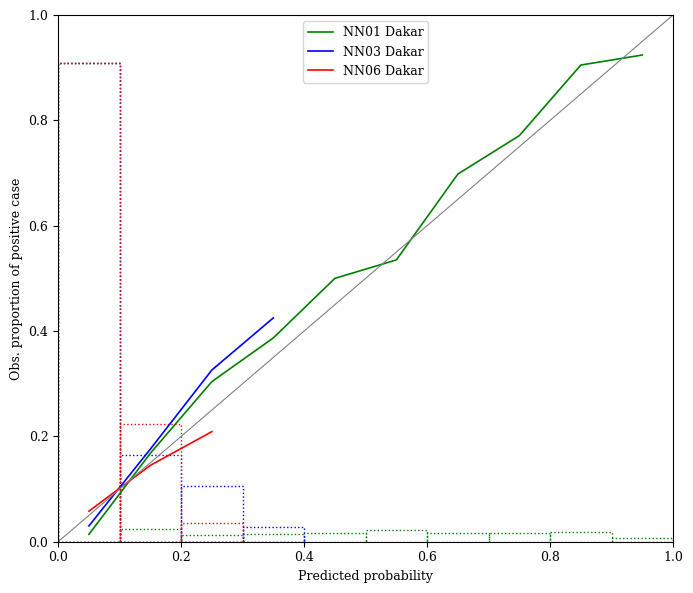

In [27]:
plt.figure(figsize=(7, 6))

plt.plot(prob_pred_t1, prob_true_t1, label=f"NN01 Dakar", color="green", linewidth=1.2)    
plt.plot(prob_pred_t3, prob_true_t3, label=f"NN03 Dakar", color="blue", linewidth=1.2)
plt.plot(prob_pred_t6, prob_true_t6, label=f"NN06 Dakar", color="red", linewidth=1.2)


no_pred_per_bin_t1 = [i/(1.1*np.max(no_pred_per_bin_t1)) for i in no_pred_per_bin_t1]
no_pred_per_bin_t3 = [i/(1.1*np.max(no_pred_per_bin_t3)) for i in no_pred_per_bin_t3]
no_pred_per_bin_t6 = [i/(1.1*np.max(no_pred_per_bin_t6)) for i in no_pred_per_bin_t6]


plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2), color="gray", linewidth=0.8)
plt.bar(prob_pred_t1, no_pred_per_bin_t1, width=0.1, linestyle=":", fill=False, edgecolor="green")
plt.bar(prob_pred_t3, no_pred_per_bin_t3, width=0.1, linestyle=":", fill=False, edgecolor="blue")
plt.bar(prob_pred_t6, no_pred_per_bin_t6, width=0.1, linestyle=":", fill=False, edgecolor="red")


plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

In [28]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)  
  plt.plot(100*fp, 100*tp, label=name, linewidth=1.2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,101])
  plt.ylim([0,101])
  plt.grid(True, linewidth=0.3)
  ax = plt.gca()
  ax.set_aspect('equal')
  plt.tight_layout()

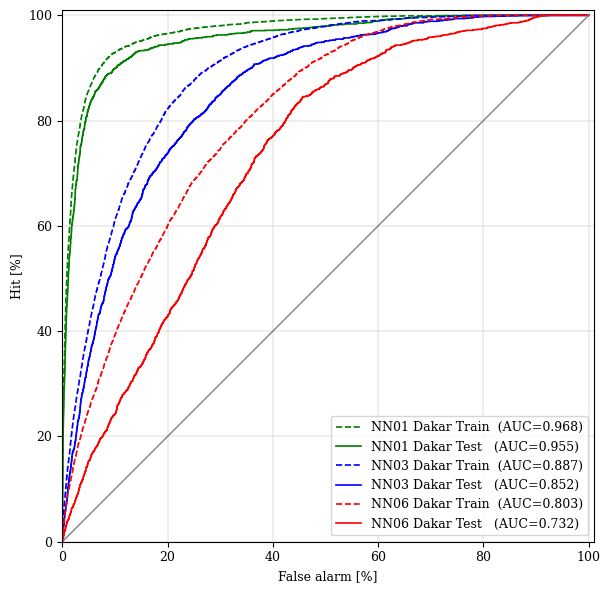

In [29]:
mpl.rcParams['figure.figsize'] = (7,6)


plot_roc(f"NN01 Dakar Train  (AUC={auc_train_t1:.3f})", y_train_t1, y_train_pred_t1, color="green", linestyle="--")
plot_roc(f"NN01 Dakar Test   (AUC={auc_test_t1:.3f})", y_test_t1, y_test_pred_t1, color="green")

plot_roc(f"NN03 Dakar Train  (AUC={auc_train_t3:.3f})", y_train_t3, y_train_pred_t3, color="blue", linestyle="--")
plot_roc(f"NN03 Dakar Test   (AUC={auc_test_t3:.3f})", y_test_t3, y_test_pred_t3, color="blue")

plot_roc(f"NN06 Dakar Train  (AUC={auc_train_t6:.3f})", y_train_t6, y_train_pred_t6, color="red", linestyle="--")
plot_roc(f"NN06 Dakar Test   (AUC={auc_test_t6:.3f})", y_test_t6, y_test_pred_t6, color="red")

plt.plot(np.arange(0,1.2,0.2)*100, np.arange(0,1.2,0.2)*100, color="gray", linewidth=1)

plt.legend(loc='lower right');

In [30]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')